In [1]:
import numpy as np
import rasterio
from scipy.stats import pearsonr

# 1. Open the rasters
# with rasterio.open("F:/Biomass tiffs/Biomass modeling/Georgia/All_trend/LOGO_sig_1984to2023_final.tif") as src_a, rasterio.open(
#     "F:/Flats imagery/Trend_nocutoffareas/flood84_23.tif"
# ) as src_b:
    
# with rasterio.open("F:/Biomass tiffs/Biomass modeling/Georgia/All_trend/LOGO_1984to2023_final.tif") as src_a, rasterio.open(
#     "F:/Flats imagery/Trend_nocutoffareas/flood84_23.tif"
# ) as src_b:
    
with rasterio.open("F:/Biomass tiffs/Biomass modeling/Georgia/All_trend/LOGO_1984to2023_Thiel_Sen.tif") as src_a, rasterio.open(
    "F:/Flats imagery/Trend_nocutoffareas/flood84_23.tif"
) as src_b:

    # Read the first band as a 2D NumPy array
    meta = src_a.meta
    arr_a = src_a.read(1).astype(np.float32)
    arr_b = src_b.read(1).astype(np.float32)

# 2. Handle NoData values (if your rasters have them)
if src_a.nodata is not None:
    arr_a[arr_a == src_a.nodata] = np.nan
if src_b.nodata is not None:
    arr_b[arr_b == src_b.nodata] = np.nan
    
arr_b_scaled = arr_b * 100 
# arr_b_log = np.where(arr_b_scaled > 0, np.log10(arr_b_scaled), np.nan)

# 3. Apply your condition
# Let's say we only want to correlate where Raster A > 50
threshold_biomass = 0
threshold_flats = 0

condition_mask = (abs(arr_a) >= threshold_biomass) & (abs(arr_b_scaled) >= threshold_flats)

# Flatten arrays to 1D and extract only the pixels meeting the condition
# We also use ~np.isnan to filter out any pre-existing NoData pixels
valid_pixels = condition_mask & ~np.isnan(arr_a) & ~np.isnan(arr_b_scaled)

flat_a = arr_a[valid_pixels]
flat_b = arr_b_scaled[valid_pixels]

# 4. Calculate the overall correlation
if len(flat_a) > 1:
    correlation_coefficient, p_value = pearsonr(flat_a, flat_b)
    print(f"Correlation Coefficient: {correlation_coefficient:.4f}")
    print(f"P-value: {p_value:.4e}")
else:
    print("Not enough valid pixels met the condition to calculate correlation.")

Correlation Coefficient: -0.2442
P-value: 0.0000e+00


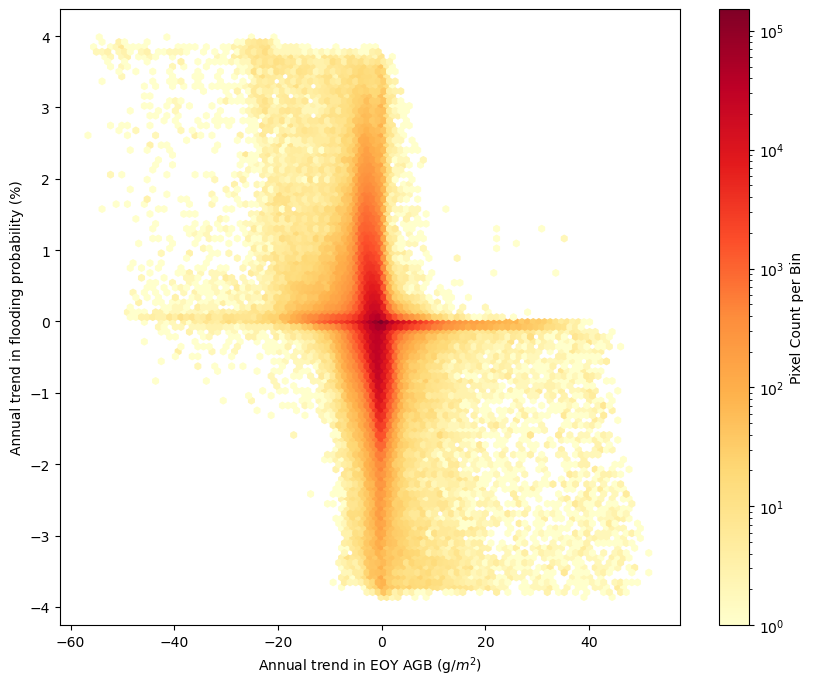

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


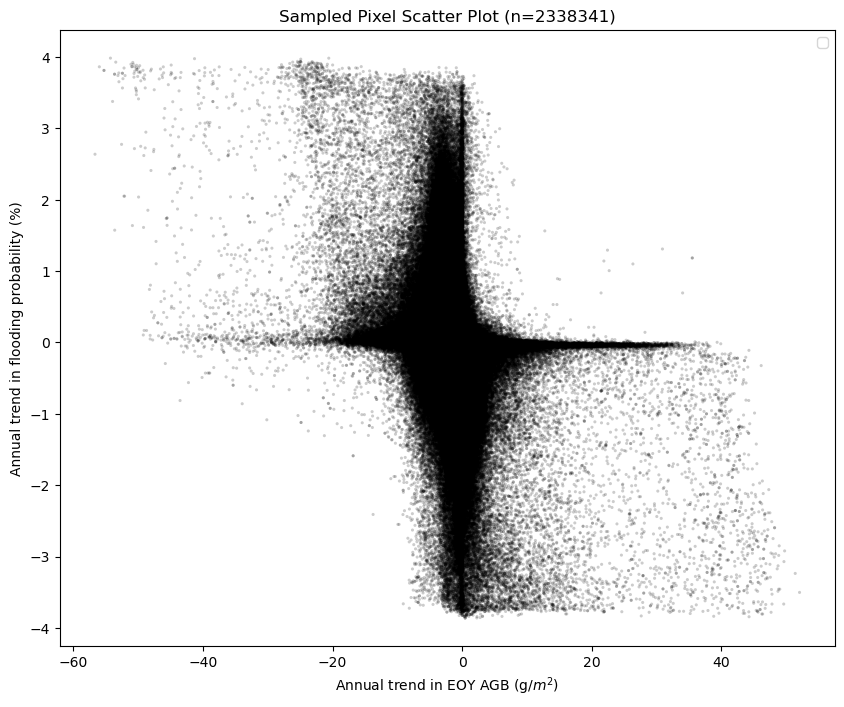

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

##Saving and displaying image
import os
output_dir = r'F:\Figures_PaperII'
file1_name = 'hexbin_corr_log.tif'
file2_name = 'scatter_corr.tif'

save1_path = os.path.join(output_dir, file1_name)
save2_path = os.path.join(output_dir, file2_name)

# Ensure we have data to plot
if len(flat_a) > 0:
    
    # METHOD 1: The Hexbin Plot (Best for Large Data)
    # This groups overlapping points into hexagons and colors them by density.
    plt.figure(figsize=(10, 8))
    hb = plt.hexbin(flat_a, flat_b, gridsize=100, cmap='YlOrRd', mincnt=1, bins = 'log')
    cb = plt.colorbar(hb, label='Pixel Count per Bin')
    
#     plt.title(f'Pixel Correlation (Where Raster A > {threshold})')
    plt.xlabel('Annual trend in EOY AGB (g/$m^2$)')
    plt.ylabel('Annual trend in flooding probability (%)')
#     plt.grid(False, linestyle='--', alpha=0.5)
#     plt.savefig(save1_path, bbox_inches='tight', dpi=1000)
    plt.show()

    # METHOD 2: Standard Scatter with Downsampling (Alternative)
    # If you strictly want dots, sample 10,000 random pixels so it renders fast.
    if len(flat_a) > 100000000000:
        idx = np.random.choice(len(flat_a), 10000, replace=False)
        sample_a = flat_a[idx]
        sample_b = flat_b[idx]
    else:
        sample_a = flat_a
        sample_b = flat_b

    plt.figure(figsize=(10, 8))
    # 'alpha=0.2' makes points translucent to see density
    plt.scatter(sample_a, sample_b, alpha=0.2, color='black', edgecolors='none', s=5) 
    
#     # Add a trend line
#     m, b = np.polyfit(sample_a, sample_b, 1)
#     plt.plot(sample_a, m*sample_a + b, color='red', label=f'Trendline (r={correlation_coefficient:.2f})')
    
    plt.title(f'Sampled Pixel Scatter Plot (n={len(sample_a)})')
    plt.xlabel('Annual trend in EOY AGB (g/$m^2$)')
    plt.ylabel('Annual trend in flooding probability (%)')
    plt.legend()
#     plt.grid(False, linestyle='--', alpha=0.5)
#     plt.savefig(save2_path, bbox_inches='tight', dpi=1000)    
    plt.show()

else:
    print("No data available to plot.")

In [3]:
import numpy as np
from scipy.optimize import curve_fit

flat_b = arr_b_scaled[valid_pixels]

# Define the sigmoid function
# x: flooding trend, y: biomass trend
def sigmoid(x, L, x0, k, b):
    """L: Maximum value (upper asymptote)

    x0: Inflection point (the exact threshold center)
    k: Steepness of the curv
    e (growth rate/drop speed)
    b: Minimum value (lower asymptote)
    """
    return L / (1 + np.exp(-k * (x - x0))) + b


# --- How to integrate it into your script ---
# flat_a = flooding trend (scaled/log), flat_b = biomass trend

# 1. Provide initial guesses (p0) to help the optimizer converge faster
# This is crucial for large, noisy datasets
initial_guesses = [
    np.max(flat_b),  # L: guess upper max biomass change
    np.median(flat_a),  # x0: guess threshold is in the middle of flooding trends
    -1.0,  # k: negative because it's a downward/negative correlation
    np.min(flat_b),  # b: guess lower min biomass change
]

# 2. Run the optimization
popt, pcov = curve_fit(
    sigmoid, flat_a, flat_b, p0=initial_guesses, maxfev=10000
)

# popt now contains your optimized parameters: [L, x0, k, b]
L_opt, x0_opt, k_opt, b_opt = popt
print(f"Optimized Threshold (Inflection Point x0): {x0_opt:.4f}")

Optimized Threshold (Inflection Point x0): -1.9937


In [4]:
# Calculate predicted values from your sigmoid model
predicted_b_sigmoid = sigmoid(flat_a, *popt)

# Calculate Sigmoid R-squared
residuals = flat_b - predicted_b_sigmoid
ss_res = np.sum(residuals**2)
ss_tot = np.sum((flat_b - np.mean(flat_b)) ** 2)
r_squared_sigmoid = 1 - (ss_res / ss_tot)

# Calculate Linear R-squared for comparison
# (Simply squaring your Pearson r value gives you the linear R-squared)
r_squared_linear = correlation_coefficient**2

print(f"Linear R-squared: {r_squared_linear:.4f}")
print(f"Sigmoid R-squared: {r_squared_sigmoid:.4f}")

Linear R-squared: 0.0596
Sigmoid R-squared: 0.0934


C:\Users\arj26323\AppData\Local\Temp\ipykernel_25108\3328802784.py:16: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0))) + b


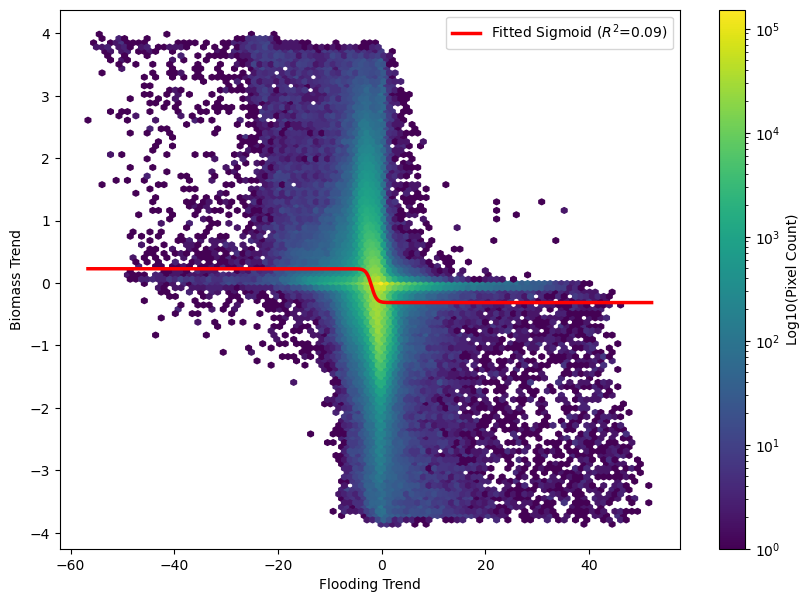

In [5]:
plt.figure(figsize=(10, 7))
hb = plt.hexbin(flat_a, flat_b, gridsize=100, cmap="viridis", mincnt=1, bins="log")
plt.colorbar(hb, label="Log10(Pixel Count)")

# Generate smooth X values across your range to plot the fitted curve
x_smooth = np.linspace(np.min(flat_a), np.max(flat_a), 500)
y_sigmoid_smooth = sigmoid(x_smooth, *popt)

# Overlay the curve
plt.plot(
    x_smooth,
    y_sigmoid_smooth,
    color="red",
    linewidth=2.5,
    label=f"Fitted Sigmoid ($R^2$={r_squared_sigmoid:.2f})",
)

plt.xlabel("Flooding Trend")
plt.ylabel("Biomass Trend")
plt.legend()
plt.show()

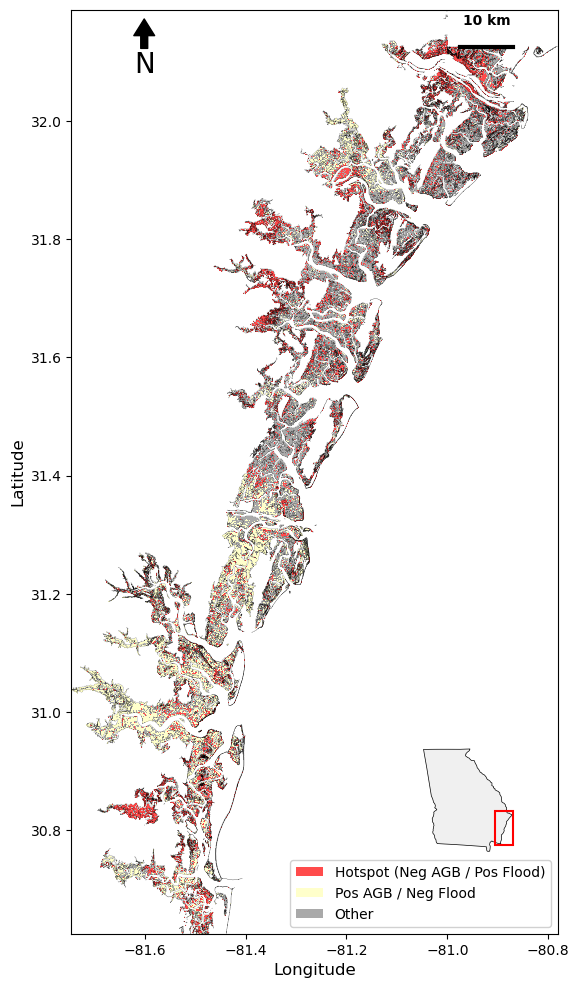

In [6]:
import numpy as np
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from rasterio.plot import plotting_extent
from matplotlib.patches import ConnectionPatch
from rasterio.transform import rowcol

# --- ASSUMING GDF, AXD, LEFT, RIGHT, BOTTOM, TOP ARE ALREADY DEFINED ---

# raster_a_path = "F:/Biomass tiffs/Biomass modeling/Georgia/All_trend/LOGO_1984to2023_final.tif"
raster_a_path = "F:/Biomass tiffs/Biomass modeling/Georgia/All_trend/LOGO_1984to2023_Thiel_Sen.tif"
raster_b_path = "F:/Flats imagery/Trend_nocutoffareas/flood84_23.tif"

base_shape = "F:/Wetlands shapefiles/GA_shapefile_wetlands/GA_estuaries.shp"
gdf = gpd.read_file(base_shape)


# 2. Define Layout (2 columns: Map is 'M', Plots are A-D)
layout = """
         MM
         MM
         MM
         MM
         """
# Now width_ratios=[3, 1] works because the layout has exactly 2 columns
fig, axd = plt.subplot_mosaic(layout, figsize=(16, 12), 
                               gridspec_kw={'width_ratios': [3, 1]})

# 1. Open and clip both rasters to ensure identical pixel grids
with rasterio.open(raster_a_path) as src_a, rasterio.open(raster_b_path) as src_b:
    
    # Project GDF to match rasters (assuming both rasters share the same CRS)
    gdf = gdf.to_crs(src_a.crs)
    
    # Clip Raster A (Biomass Trend)
    out_img_a, out_transform = mask(src_a, gdf.geometry, crop=True)
    arr_a = out_img_a[0].astype(np.float32)
    
    # Clip Raster B (Flooding Trend)
    out_img_b, _ = mask(src_b, gdf.geometry, crop=True)
    arr_b = out_img_b[0].astype(np.float32)
    
    # Get the bounding extent for spatial plotting
    clip_extent = plotting_extent(arr_a, out_transform)
    
    # Handle NoData values by turning them into NaNs
    if src_a.nodata is not None: arr_a[arr_a == src_a.nodata] = np.nan
    if src_b.nodata is not None: arr_b[arr_b == src_b.nodata] = np.nan
        


# 2. Build the Categorical Logic
# Create boolean masks for your conditions
red_condition   = (arr_a < 0) & (arr_b > 0)  # Neg Biomass, Pos Flooding
green_condition = (arr_a > 0) & (arr_b < 0)  # Pos Biomass, Neg Flooding

# We also need to track where data is missing in either raster
nan_mask = np.isnan(arr_a) | np.isnan(arr_b)

# Define conditions and their corresponding integer IDs
# 1 = Red, 2 = Green, 0 = Gray (Default/Any other combination)
conditions = [red_condition, green_condition]
choices = [1, 2]

# Map out the values (default to 0 for the gray category)
classified_raster = np.select(conditions, choices, default=0).astype(np.float32)

# Make sure true NaNs stay transparent rather than turning gray
classified_raster[nan_mask] = np.nan

# 3. Define the Discrete Colormap
# Order matches our integer choices: 0=Gray, 1=Red, 2=Gold
colors = ['#A9A9A9', '#FF4B4B', '#FFFFCB'] 
categorical_cmap = ListedColormap(colors)
categorical_cmap.set_bad(color='none') # Ensures NaNs are transparent

# Define boundaries so matplotlib assigns integers cleanly to colors
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, categorical_cmap.N)

# 4. Plotting
img = axd['M'].imshow(classified_raster, 
                      cmap=categorical_cmap, 
                      norm=norm,
                      interpolation='nearest',
                      extent=clip_extent)
left, right, bottom, top = clip_extent

# Keep map zoomed in
# axd['M'].set_xlim(left, right)
# axd['M'].set_ylim(bottom, top)

# Overlay the shapefile
gdf.plot(ax=axd['M'], facecolor='none', edgecolor='black', linewidth=0.1, zorder=1)

# --- OPTIONAL: Add a clean categorical legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF4B4B', edgecolor='none', label='Hotspot (Neg AGB / Pos Flood)'),
    Patch(facecolor='#FFFFCB', edgecolor='none', label='Pos AGB / Neg Flood'),
    Patch(facecolor='#A9A9A9', edgecolor='none', label='Other')
]
axd['M'].legend(handles=legend_elements, loc='lower right', framealpha=0.9)

# Axis Labels
ax_m = axd['M']
ax_m.set_xlabel("Longitude", fontsize=12)
ax_m.set_ylabel("Latitude", fontsize=12)

# Add North Arrow
x, y, arrow_length = 0.15, 0.99, 0.05
axd['M'].annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
                  arrowprops=dict(facecolor='black', width=5, headwidth=15),
                  ha='center', va='center', fontsize=20, xycoords='axes fraction')


# --- 5. ADD SCALE BAR (Calculated for Georgia's latitude) ---
# At ~30.8°N, 1 degree lon is roughly 95.6 km. 
# So, 10km is ~0.1046 degrees.
scale_len_deg = 10 / 95.6  
sb_x = left + (right - left) * 0.80 # Start 80% from left
sb_y = bottom + (top - bottom) * 0.96 # Start 96% from bottom

axd['M'].plot([sb_x, sb_x + scale_len_deg], [sb_y, sb_y], color='black', lw=3, zorder=5)
axd['M'].text(sb_x + (scale_len_deg/2), sb_y + (top-bottom)*0.02, '10 km', 
              ha='center', va='bottom', fontsize=10, fontweight='bold')

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches

# 1. Create the inset axis (loc=4 is lower right, loc=1 is upper right)
ax_inset = inset_axes(axd['M'], width="20%", height="20%", loc=4, borderpad=3)

# 2. Load and plot the Georgia Shapefile
ga_gdf = gpd.read_file("F:/US states/Georgia.shp")
ga_gdf = ga_gdf.to_crs(src_a.crs) # Match CRS to your raster
ga_gdf.plot(ax=ax_inset, facecolor='#f0f0f0', edgecolor='black', linewidth=0.5)

# 3. Add a "You Are Here" rectangle
# Using the 'left, bottom, right, top' variables you already defined from src2.bounds
rect = patches.Rectangle((left, bottom), right - left, top - bottom, 
                         linewidth=1.5, edgecolor='red', facecolor='none', zorder=10)
ax_inset.add_patch(rect)

# 4. Clean up the inset (remove coordinates/spines for a "clean" look)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
for spine in ax_inset.spines.values():
    spine.set_visible(False)
    ''

##Save at high res
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'FLATS_AGB_CORR_THEIL_SEN.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()

In [98]:
##Finito

CRS.from_wkt('GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]')